In [1]:
''' START -> OUTLINE -> BLOG  -> END'''

' START -> OUTLINE -> BLOG  -> END'

In [2]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict 
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [3]:
load_dotenv()
model = ChatOpenAI(model = 'gpt-4o-mini')

In [4]:
class BlogState(TypedDict):
    title : str
    outline : str
    content : str

In [5]:
def create_outline(state : BlogState) -> BlogState:
    title = state['title']
    
    prompt = f'Create a detailed outline for a blog on the topic - {title }'
    outline = model.invoke(prompt).content
    
    state['outline'] = outline
    return state

In [6]:
def create_content(state : BlogState) -> BlogState:
    outline = state['outline']
    topic = state['title']
    
    prompt = f'Create a blog on the title - {topic} using the following outline {outline}'
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [7]:
#Create Graph
graph = StateGraph(BlogState)

In [8]:
#ADD node
graph.add_node('create_outline' , create_outline)
graph.add_node('create_content' , create_content)

In [9]:
#Add Edges
graph.add_edge(START , 'create_outline')
graph.add_edge('create_outline' , 'create_content')
graph.add_edge('create_content' , END)

workflow  = graph.compile()

In [14]:
initial_state =  {'title' : 'Junk Food'}
final_state = workflow.invoke(initial_state)
print(final_state['content'])

# The Ultimate Guide to Junk Food

## Introduction

Junk food is a term used to describe food items that are high in calories but low in nutritional value. Common examples include potato chips, sugary drinks, fast food, and heavily processed snacks. The prevalence of junk food in modern diets is staggering; it's become a staple in households, schools, and workplaces. The purpose of this blog is to delve into the origins of junk food, its impact on health, the societal implications of its consumption, and to provide viable alternatives for those looking to improve their diets.

## I. Understanding Junk Food

### A. Definition and Characteristics

Junk food is characterized by its high calorie count relative to its nutrient content. These foods are often laden with sugars, unhealthy fats, and preservatives, making them a poor choice for a balanced diet. Common types of junk food include snacks like chips and candies, fast food options such as burgers and fries, sugary drinks, and various

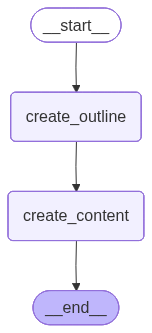

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())